In [1]:
"""
neural-bites.py
=====================
Fixed version of the neural-bites notebook with all critical issues resolved.

Key fixes:
  1. Correct 15-class labeling (Fruit × Condition)
  2. Stratified train/val/test split
  3. Two-phase training (freeze backbone → unfreeze with discriminative LR)
  4. Consistent early stopping (single metric)
  5. Stratified K-Fold cross-validation for robust evaluation
  6. Proper val_loss computation
  7. Reproducibility seeds
  8. Updated deprecated APIs

Author: Mohammod Hamed Hasan (original) — fixed by Claude review
"""

'\nneural-bites-fixed.py\n=====================\nFixed version of the neural-bites notebook with all critical issues resolved.\n\nKey fixes:\n  1. Correct 15-class labeling (Fruit × Condition)\n  2. Stratified train/val/test split\n  3. Two-phase training (freeze backbone → unfreeze with discriminative LR)\n  4. Consistent early stopping (single metric)\n  5. Stratified K-Fold cross-validation for robust evaluation\n  6. Proper val_loss computation\n  7. Reproducibility seeds\n  8. Updated deprecated APIs\n\nAuthor: Mohammod Hamed Hasan (original) — fixed by Claude review\n'

# Cell 0 — Setup & Configuration

In [2]:
import os
import glob
import copy
import time
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Paths (Kaggle environment) ───────────────────────────────────────
import kagglehub
dataset_path = kagglehub.dataset_download("ahmadfauzi89/fruitvision-mendeley")
DATA_DIR = os.path.join(dataset_path, "Fruits Original")

MODEL_SAVE_PATH = "best_fruit_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


# Cell 1 — Dataset Class (15-class Fruit×Condition labeling)
#
**BUG IN ORIGINAL:** `ImageFolder(data_dir)` used fruit names (Apple, Banana, ...)
as classes, ignoring the condition subfolders (Fresh, Rotten, Formalin-mixed).
The model was learning to distinguish fruit types — a trivially easy task — instead
of detecting formalin contamination, which is the actual project goal.
#
**FIX:** Walk two levels deep. Class = "FruitName-Condition" (e.g., "Apple-Fresh",
"Banana-Formalin-mixed"). This gives 15 classes (5 fruits × 3 conditions).

In [3]:
class FruitConditionDataset(Dataset):
    """
    Dataset that uses BOTH the fruit name AND condition as the class label.

    Expected directory structure:
        data_dir/
            Apple/
                Fresh/          ← images
                Rotten/         ← images
                Formalin-mixed/ ← images
            Banana/
                Fresh/ ...

    Class label format: "Apple-Fresh", "Apple-Rotten", "Banana-Formalin-mixed", etc.
    """

    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []  # list of (path, class_idx)

        # Walk: root / fruit_name / condition / image_file
        class_names = set()
        all_entries = []

        for fruit_name in sorted(os.listdir(root_dir)):
            fruit_path = os.path.join(root_dir, fruit_name)
            if not os.path.isdir(fruit_path):
                continue
            for condition in sorted(os.listdir(fruit_path)):
                condition_path = os.path.join(fruit_path, condition)
                if not os.path.isdir(condition_path):
                    continue
                class_label = f"{fruit_name}-{condition}"
                class_names.add(class_label)
                for fname in os.listdir(condition_path):
                    ext = os.path.splitext(fname)[1].lower()
                    if ext in self.VALID_EXTENSIONS:
                        all_entries.append((
                            os.path.join(condition_path, fname),
                            class_label
                        ))

        self.classes = sorted(list(class_names))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = [(p, self.class_to_idx[c]) for p, c in all_entries]
        self.targets = [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Instantiate and inspect ──────────────────────────────────────────
full_dataset = FruitConditionDataset(DATA_DIR)
print(f"Total images: {len(full_dataset)}")
print(f"Classes ({len(full_dataset.classes)}): {full_dataset.classes}")

# Show class distribution
dist = Counter(full_dataset.targets)
for cls_name in full_dataset.classes:
    idx = full_dataset.class_to_idx[cls_name]
    print(f"  {cls_name}: {dist[idx]} images")

Total images: 10154
Classes (15): ['Apple-Formalin-mixed', 'Apple-Fresh', 'Apple-Rotten', 'Banana-Formalin-mixed', 'Banana-Fresh', 'Banana-Rotten', 'Grape-Formalin-mixed', 'Grape-Fresh', 'Grape-Rotten', 'Mango-Formalin-mixed', 'Mango-Fresh', 'Mango-Rotten', 'Orange-Formalin-mixed', 'Orange-Fresh', 'Orange-Rotten']
  Apple-Formalin-mixed: 643 images
  Apple-Fresh: 765 images
  Apple-Rotten: 630 images
  Banana-Formalin-mixed: 660 images
  Banana-Fresh: 749 images
  Banana-Rotten: 632 images
  Grape-Formalin-mixed: 610 images
  Grape-Fresh: 770 images
  Grape-Rotten: 630 images
  Mango-Formalin-mixed: 616 images
  Mango-Fresh: 763 images
  Mango-Rotten: 630 images
  Orange-Formalin-mixed: 647 images
  Orange-Fresh: 753 images
  Orange-Rotten: 656 images


# Cell 2 — Visualize Samples (one per class)

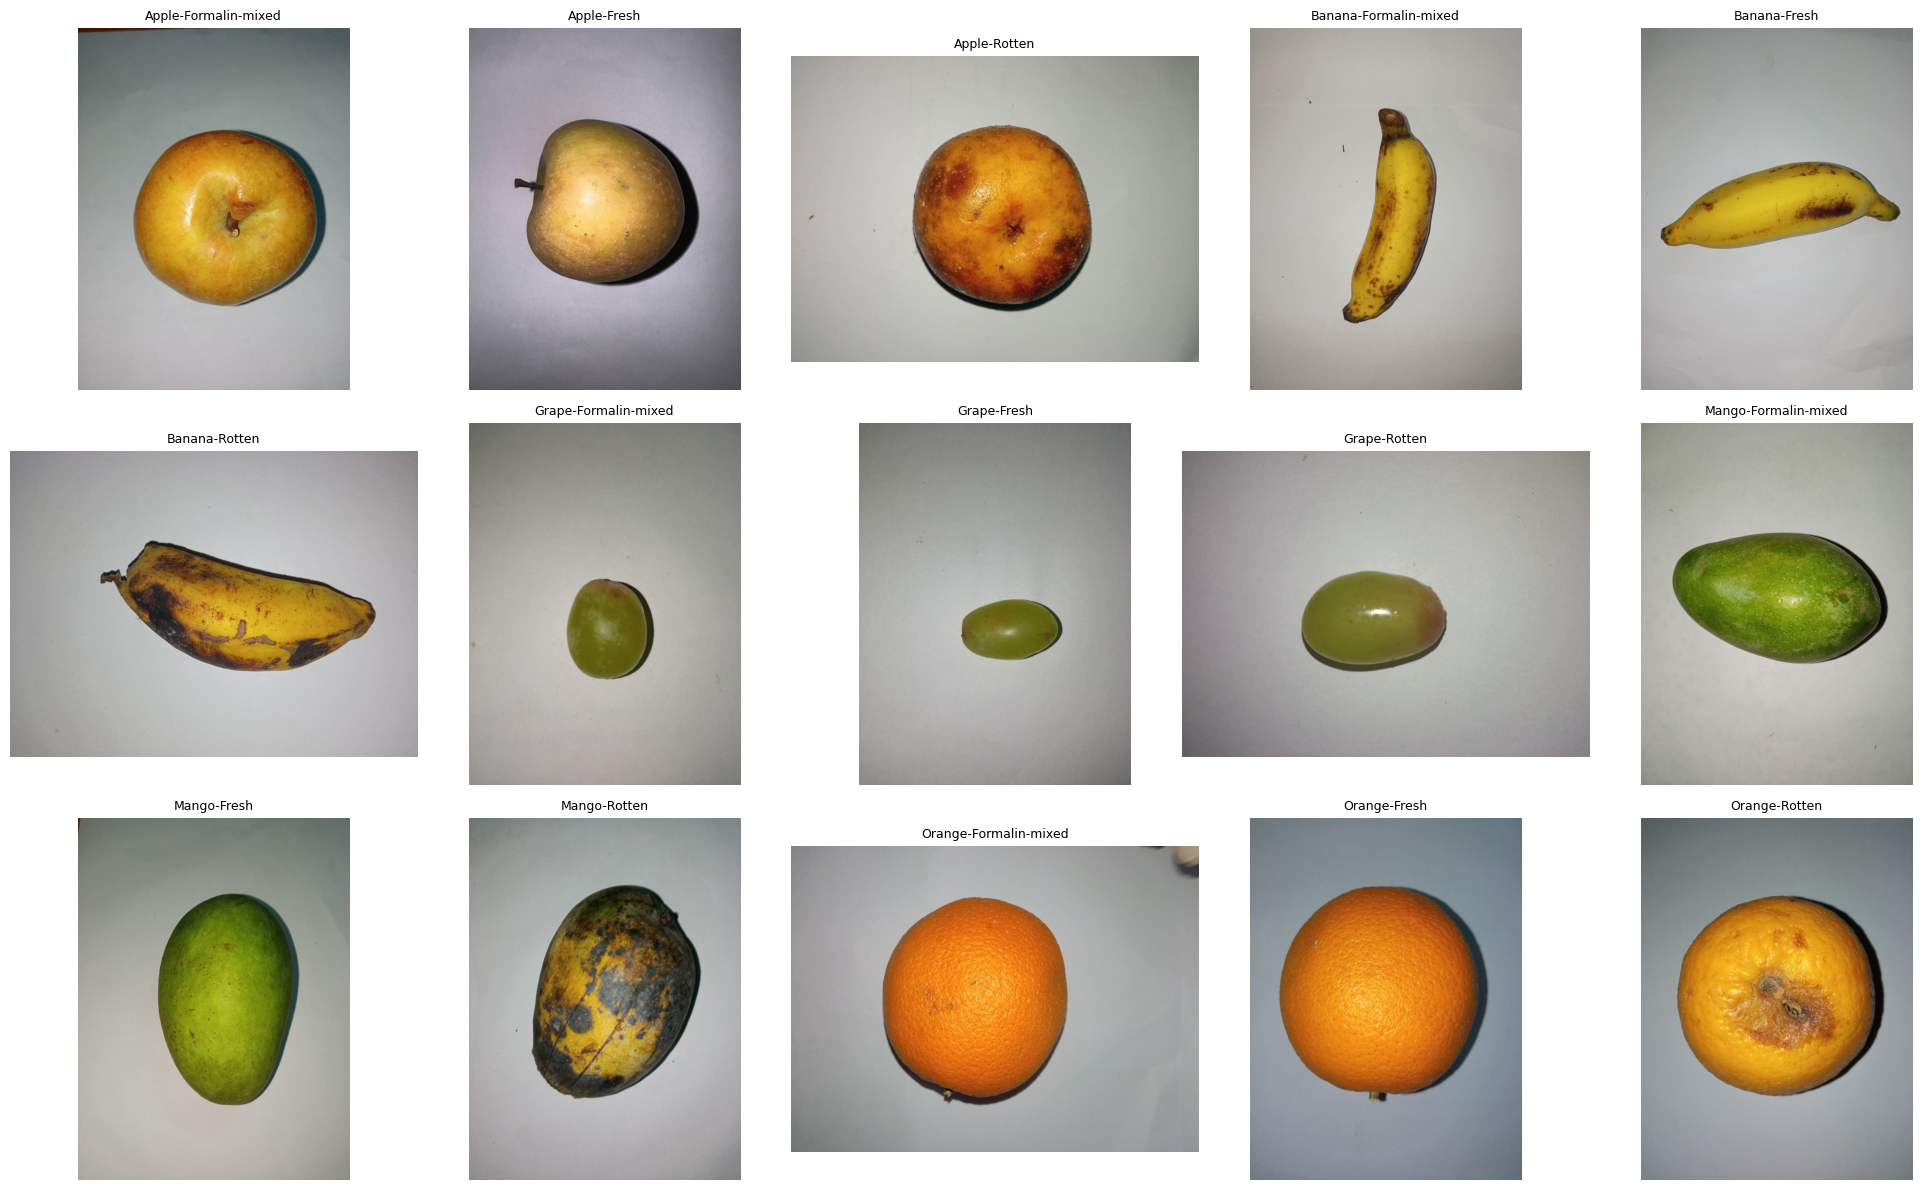

In [4]:
n_classes = len(full_dataset.classes)
cols = min(5, n_classes)
rows = (n_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).flatten()

# Get one sample per class
class_shown = set()
for path, label in full_dataset.samples:
    if label not in class_shown:
        ax = axes[label]
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(full_dataset.classes[label], fontsize=9)
        ax.axis('off')
        class_shown.add(label)
    if len(class_shown) == n_classes:
        break

for i in range(n_classes, len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Cell 3 — Transforms (without CLAHE preprocessing)

In [5]:
# NO CLAHE preprocessing — it was destroying formalin's color-loss signature.
# We use minimal augmentation to preserve diagnostic features:
#   - Small brightness jitter (simulates lighting variation)
#   - Horizontal flip only (vertical flip breaks position-specific pathology)
#   - Small rotation (fruits at slight angles are realistic)
IMG_SIZE = 384  # Higher resolution helps distinguish formalin (uniform) vs rot (localized)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.05),  # Very minimal — preserves color diagnostics
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Cell 4 — Stratified Train/Val/Test Split (FIXED)
#
**BUG IN ORIGINAL:** `random_split` doesn't stratify. With class imbalance (Formalin
images are likely the minority), some splits could have very few samples of rare classes.
#
**FIX:** Use `StratifiedShuffleSplit` so every split has the same class proportions.

In [6]:
class TransformedSubset(Dataset):
    """Wraps a list of indices into a base dataset with a specific transform."""

    def __init__(self, base_dataset, indices, transform=None):
        self.base = base_dataset
        self.indices = list(indices)
        self.transform = transform
        self.targets = [base_dataset.targets[i] for i in self.indices]
        self.classes = base_dataset.classes

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, label = self.base.samples[real_idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.indices)


# Split: 70% train, 15% val, 15% test — stratified by class
labels = np.array(full_dataset.targets)

# First split: 70% train vs 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))

# Second split: 50% of temp = 15% val, 50% of temp = 15% test
temp_labels = labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

train_data = TransformedSubset(full_dataset, train_idx, transform=train_transform)
val_data   = TransformedSubset(full_dataset, val_idx,   transform=val_transform)
test_data  = TransformedSubset(full_dataset, test_idx,  transform=val_transform)

print(f"Training set:   {len(train_data)} images")
print(f"Validation set: {len(val_data)} images")
print(f"Test set:       {len(test_data)} images")

# Verify stratification
for name, subset in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    c = Counter(subset.targets)
    total = len(subset)
    print(f"\n{name} distribution:")
    for cls_name in full_dataset.classes:
        ci = full_dataset.class_to_idx[cls_name]
        print(f"  {cls_name}: {c.get(ci, 0)} ({100*c.get(ci,0)/total:.1f}%)")

Training set:   7107 images
Validation set: 1523 images
Test set:       1524 images

Train distribution:
  Apple-Formalin-mixed: 450 (6.3%)
  Apple-Fresh: 536 (7.5%)
  Apple-Rotten: 441 (6.2%)
  Banana-Formalin-mixed: 462 (6.5%)
  Banana-Fresh: 524 (7.4%)
  Banana-Rotten: 442 (6.2%)
  Grape-Formalin-mixed: 427 (6.0%)
  Grape-Fresh: 539 (7.6%)
  Grape-Rotten: 441 (6.2%)
  Mango-Formalin-mixed: 431 (6.1%)
  Mango-Fresh: 534 (7.5%)
  Mango-Rotten: 441 (6.2%)
  Orange-Formalin-mixed: 453 (6.4%)
  Orange-Fresh: 527 (7.4%)
  Orange-Rotten: 459 (6.5%)

Val distribution:
  Apple-Formalin-mixed: 96 (6.3%)
  Apple-Fresh: 114 (7.5%)
  Apple-Rotten: 95 (6.2%)
  Banana-Formalin-mixed: 99 (6.5%)
  Banana-Fresh: 112 (7.4%)
  Banana-Rotten: 95 (6.2%)
  Grape-Formalin-mixed: 92 (6.0%)
  Grape-Fresh: 115 (7.6%)
  Grape-Rotten: 95 (6.2%)
  Mango-Formalin-mixed: 93 (6.1%)
  Mango-Fresh: 114 (7.5%)
  Mango-Rotten: 95 (6.2%)
  Orange-Formalin-mixed: 97 (6.4%)
  Orange-Fresh: 113 (7.4%)
  Orange-Rotten: 98 (

# Cell 5 — Weighted Sampler & Data Loaders

In [7]:
from torch.utils.data import WeightedRandomSampler

train_labels = np.array(train_data.targets)
class_counts = np.array([np.sum(train_labels == c) for c in range(len(full_dataset.classes))])
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[t] for t in train_labels], dtype=torch.double)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights))

BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Class weights: {dict(zip(full_dataset.classes, class_weights.round(5)))}")
print("Data loaders ready.")

Class weights: {'Apple-Formalin-mixed': np.float64(0.00222), 'Apple-Fresh': np.float64(0.00187), 'Apple-Rotten': np.float64(0.00227), 'Banana-Formalin-mixed': np.float64(0.00216), 'Banana-Fresh': np.float64(0.00191), 'Banana-Rotten': np.float64(0.00226), 'Grape-Formalin-mixed': np.float64(0.00234), 'Grape-Fresh': np.float64(0.00186), 'Grape-Rotten': np.float64(0.00227), 'Mango-Formalin-mixed': np.float64(0.00232), 'Mango-Fresh': np.float64(0.00187), 'Mango-Rotten': np.float64(0.00227), 'Orange-Formalin-mixed': np.float64(0.00221), 'Orange-Fresh': np.float64(0.0019), 'Orange-Rotten': np.float64(0.00218)}
Data loaders ready.


# Cell 6 — Model Setup (two-phase training)
#
**BUG IN ORIGINAL:** `feature_extract=False` unfroze everything from epoch 0 with
lr=0.001, shattering pretrained weights before the random classifier head stabilized.
#
**FIX:** Build the model with a frozen backbone. Phase 1 warms up the head only.
Phase 2 unfreezes with discriminative LR (backbone 10× lower than head).

In [8]:
NUM_CLASSES = len(full_dataset.classes)


def build_mobilenet(num_classes):
    """Build MobileNetV2 with a custom head, backbone frozen by default."""
    net = models.mobilenet_v2(weights='DEFAULT')  # ← fixed: was pretrained=True

    # Freeze backbone
    for param in net.features.parameters():
        param.requires_grad = False

    # Custom classifier head
    net.classifier[1] = nn.Sequential(
        nn.Linear(net.last_channel, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return net.to(DEVICE)


model = build_mobilenet(NUM_CLASSES)
print(f"MobileNetV2 built for {NUM_CLASSES} classes (backbone frozen).")

MobileNetV2 built for 15 classes (backbone frozen).


# Cell 6b — PairAwareCrossEntropy (fixes Formalin ↔ Rotten confusion)
#
Standard cross-entropy treats all mistakes equally. But Formalin ↔ Rotten
confusion is more dangerous for a fruit-safety app (both look "discolored"
and both are unsafe, but formalin is chemical contamination while rot is
biological). We add an extra penalty when the model confuses them.

In [9]:
class PairAwareCrossEntropy(nn.Module):
    """
    Weighted cross-entropy that adds extra penalty when the model confuses
    same-fruit Formalin ↔ Rotten pairs (e.g., Apple-Formalin-mixed ↔ Apple-Rotten).
    """
    def __init__(self, class_names, base_weights, confusion_penalty=2.0):
        super().__init__()
        self.base_weights = base_weights
        n = len(class_names)

        # penalty[true_idx][pred_idx] = extra multiplier when confused
        penalty = torch.ones(n, n)
        for i, name_i in enumerate(class_names):
            for j, name_j in enumerate(class_names):
                if i == j:
                    continue
                fruit_i, cond_i = name_i.rsplit('-', 1)
                fruit_j, cond_j = name_j.rsplit('-', 1)
                # Same fruit, but Formalin vs Rotten pair
                if fruit_i == fruit_j and \
                   {cond_i, cond_j} == {'Formalin-mixed', 'Rotten'}:
                    penalty[i][j] = confusion_penalty

        self.register_buffer('penalty', penalty)

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        per_sample_loss = F.nll_loss(
            log_probs, targets,
            weight=self.base_weights, reduction='none'
        )
        preds = logits.argmax(dim=1)
        extra_penalty = self.penalty[targets, preds]
        return (per_sample_loss * extra_penalty).mean()


class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# Toggle: use pair-aware loss or standard weighted CE
USE_PAIR_AWARE_LOSS = True

if USE_PAIR_AWARE_LOSS:
    criterion = PairAwareCrossEntropy(
        class_names=full_dataset.classes,
        base_weights=class_weights_tensor,
        confusion_penalty=2.0  # 2× penalty for Formalin ↔ Rotten
    ).to(DEVICE)
    print("Using PairAwareCrossEntropy (Formalin ↔ Rotten penalty = 2.0)")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    print("Using standard weighted CrossEntropyLoss")

Using PairAwareCrossEntropy (Formalin ↔ Rotten penalty = 2.0)


# Cell 7 — Training Loop (consistent early stopping + proper val_loss)
#
**BUGS FIXED:**
- Early stopping and model saving now both use val_accuracy (was inconsistent)
- val_loss is properly computed (was stored as 0.0 in Part 2)
- Two-phase training: Phase 1 = head only, Phase 2 = full model with discriminative LR
- Weight decay added to optimizer

In [11]:
# %% [markdown]
# # Cell 7 — Training Loop with Checkpoint Resume Support

# %%
import os
import copy
from pathlib import Path

# ── Checkpoint paths ──────────────────────────────────────────────
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
PHASE1_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "phase1_checkpoint.pt")
PHASE2_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "phase2_checkpoint.pt")


def train_model(model, train_loader, val_loader, criterion, 
                num_epochs=30, patience=5, lr_head=1e-3, 
                lr_backbone=None, phase_name="",
                resume_from=None, start_epoch=0):
    """
    Train with checkpoint support for resuming.
    
    Args:
        resume_from: Path to checkpoint file (or None)
        start_epoch: Starting epoch (0 if no resume)
    """
    
    # ── Build optimizer ──────────────────────────────────────────
    if lr_backbone is not None:
        # Discriminative LR: backbone gets lower LR
        backbone_params = [p for n, p in model.named_parameters()
                           if not n.startswith('classifier') and p.requires_grad]
        head_params = [p for n, p in model.named_parameters()
                       if n.startswith('classifier')]
        optimizer = torch.optim.Adam([
            {'params': backbone_params, 'lr': lr_backbone, 'weight_decay': 1e-4},
            {'params': head_params, 'lr': lr_head, 'weight_decay': 1e-4},
        ])
    else:
        head_params = [p for p in model.classifier.parameters()]
        optimizer = torch.optim.Adam(head_params, lr=lr_head, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=3
    )

    # ── Initialize training state ───────────────────────────────
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())
    stop_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    current_epoch = start_epoch

    # ── Load checkpoint if resuming ─────────────────────────────
    if resume_from and os.path.exists(resume_from):
        print(f"🔄 Resuming from checkpoint: {resume_from}")
        checkpoint = torch.load(resume_from, map_location=DEVICE)
        
        # Load model state
        model.load_state_dict(checkpoint['model_state_dict'])
        best_wts = checkpoint['best_wts']
        best_acc = checkpoint['best_acc']
        current_epoch = checkpoint['epoch'] + 1  # Start from next epoch
        stop_counter = checkpoint['stop_counter']
        history = checkpoint['history']
        
        # Load optimizer state
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        print(f"   Resumed from epoch {checkpoint['epoch']}")
        print(f"   Best val accuracy so far: {best_acc:.4f}")
        print(f"   Stop counter: {stop_counter}/{patience}")
    else:
        if resume_from:
            print(f"⚠️ Checkpoint not found: {resume_from}")
        print(f"🆕 Starting fresh training from epoch {current_epoch}")

    # ── Training loop ────────────────────────────────────────────
    for epoch in range(current_epoch, num_epochs):
        print(f"\n{phase_name} Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ['train', 'val']:
            is_train = (phase == 'train')
            model.train() if is_train else model.eval()
            loader = train_loader if is_train else val_loader

            running_loss = 0.0
            running_correct = 0
            total = 0

            for inputs, labels in tqdm(loader, desc=phase.capitalize(), leave=False):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(is_train):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = outputs.argmax(dim=1)

                    if is_train:
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_correct += (preds == labels).sum().item()
                total += inputs.size(0)

            epoch_loss = running_loss / total
            epoch_acc = running_correct / total

            if is_train:
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                print(f"  Train Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                print(f"  Val   Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

                scheduler.step(epoch_acc)

                # ── Save best model ──────────────────────────────
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    torch.save({
                        'model_state_dict': best_wts,
                        'classes': full_dataset.classes,
                        'epoch': epoch,
                        'best_acc': best_acc,
                    }, MODEL_SAVE_PATH)
                    print(f"  ⭐ New best val accuracy: {best_acc:.4f} — saved.")
                    stop_counter = 0
                else:
                    stop_counter += 1

        # ── SAVE CHECKPOINT AFTER EACH EPOCH ────────────────────
        # This saves everything needed to resume training
        checkpoint_data = {
            'epoch': epoch,
            'best_acc': best_acc,
            'best_wts': best_wts,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'stop_counter': stop_counter,
            'history': history,
            'phase_name': phase_name,
            'lr_backbone': lr_backbone,
            'lr_head': lr_head,
        }
        
        # Save to phase-specific checkpoint
        if lr_backbone is None:
            checkpoint_path = PHASE1_CHECKPOINT
        else:
            checkpoint_path = PHASE2_CHECKPOINT
        
        torch.save(checkpoint_data, checkpoint_path)
        print(f"  💾 Checkpoint saved to {checkpoint_path} (epoch {epoch+1})")

        # ── Early stopping ───────────────────────────────────────
        if stop_counter >= patience:
            print(f"\n🛑 Early stopping after {patience} epochs without improvement.")
            break

    # ── Load best weights before returning ──────────────────────
    model.load_state_dict(best_wts)
    
    return model, history


# ── Helper: List checkpoints ──────────────────────────────────────
def list_checkpoints():
    """List all available checkpoints with their status."""
    print("\n📋 Checkpoint Status:")
    print("-" * 50)
    
    for name, path in [("Phase 1", PHASE1_CHECKPOINT), 
                       ("Phase 2", PHASE2_CHECKPOINT)]:
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=DEVICE)
            print(f"{name}:")
            print(f"   File: {path}")
            print(f"   Epoch: {checkpoint['epoch']+1}")
            print(f"   Best val acc: {checkpoint['best_acc']:.4f}")
            print(f"   Stop counter: {checkpoint['stop_counter']}")
            size_mb = os.path.getsize(path) / 1024 / 1024
            print(f"   Size: {size_mb:.1f} MB")
        else:
            print(f"{name}: ❌ Not found")
    print("-" * 50)


# ── Smart resume: detects which phase and resumes ────────────────
def resume_training(model):
    """
    Smart resume: detects which phase we're in and continues.
    
    Args:
        model: The model to train (passed as argument to avoid UnboundLocalError)
    """
    history_p1 = None  # Initialize for Phase 1 history
    
    # ── Check Phase 1 status ─────────────────────────────────────
    print("=" * 55)
    print("PHASE 1 — Head warmup (backbone frozen)")
    print("=" * 55)
    
    phase1_complete = False
    if os.path.exists(PHASE1_CHECKPOINT):
        checkpoint = torch.load(PHASE1_CHECKPOINT, map_location=DEVICE)
        # Phase 1 has 5 epochs (0-4)
        if checkpoint['epoch'] >= 4:
            phase1_complete = True
            print("✅ Phase 1 already completed (5 epochs). Skipping to Phase 2.")
            # Load the model from Phase 1 checkpoint
            model.load_state_dict(checkpoint['model_state_dict'])
            history_p1 = checkpoint['history']
            print(f"   Loaded Phase 1 model from {PHASE1_CHECKPOINT}")
    
    if not phase1_complete:
        resume_from = PHASE1_CHECKPOINT if os.path.exists(PHASE1_CHECKPOINT) else None
        
        model, history_p1 = train_model(
            model, train_loader, val_loader, criterion,
            num_epochs=5, patience=5, lr_head=1e-3, lr_backbone=None,
            phase_name="[P1]",
            resume_from=resume_from,
            start_epoch=0
        )

    # ── Phase 2: Full Fine-Tuning ────────────────────────────────
    print("\n" + "=" * 55)
    print("PHASE 2 — Full fine-tuning (discriminative LR)")
    print("=" * 55)

    # Unfreeze backbone if it's still frozen
    backbone_frozen = all(not p.requires_grad for p in model.features.parameters())
    if backbone_frozen:
        print("   Unfreezing backbone for Phase 2...")
        for param in model.features.parameters():
            param.requires_grad = True
    else:
        print("   Backbone already unfrozen.")

    # Resume Phase 2 if checkpoint exists
    resume_from = PHASE2_CHECKPOINT if os.path.exists(PHASE2_CHECKPOINT) else None
    
    model, history_p2 = train_model(
        model, train_loader, val_loader, criterion,
        num_epochs=25, patience=6, lr_head=1e-3, lr_backbone=1e-4,
        phase_name="[P2]",
        resume_from=resume_from,
        start_epoch=0
    )

    # ── Merge histories ──────────────────────────────────────────
    # If Phase 1 was loaded from checkpoint, history_p1 is already defined
    if history_p1 is None:
        # This shouldn't happen, but just in case
        history_p1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    history = {k: history_p1[k] + history_p2[k] for k in history_p1}
    
    # ── Save final model ─────────────────────────────────────────
    torch.save({
        'model_state_dict': model.state_dict(),
        'classes': full_dataset.classes,
        'history': history,
    }, MODEL_SAVE_PATH)
    print(f"\n✅ Training complete! Final model saved to {MODEL_SAVE_PATH}")
    
    return model, history


# ── EXECUTION ──────────────────────────────────────────────────────

# Check if there are existing checkpoints
list_checkpoints()

# Run training with resume support - PASS THE MODEL AS ARGUMENT
model, history = resume_training(model)

# Optionally clean up checkpoints after training
# (Uncomment to remove checkpoints after successful training)
# import os
# for path in [PHASE1_CHECKPOINT, PHASE2_CHECKPOINT]:
#     if os.path.exists(path):
#         os.remove(path)
#         print(f"🗑️ Removed: {path}")


📋 Checkpoint Status:
--------------------------------------------------
Phase 1: ❌ Not found
Phase 2: ❌ Not found
--------------------------------------------------
PHASE 1 — Head warmup (backbone frozen)
🆕 Starting fresh training from epoch 0

[P1] Epoch 1/5
----------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

  Train Loss: 0.0030  Acc: 0.5851


Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Val   Loss: 0.0025  Acc: 0.6664
  ⭐ New best val accuracy: 0.6664 — saved.
  💾 Checkpoint saved to checkpoints/phase1_checkpoint.pt (epoch 1)

[P1] Epoch 2/5
----------------------------------------


...

  Val   Loss: 0.0001  Acc: 0.9961
  💾 Checkpoint saved to checkpoints/phase2_checkpoint.pt (epoch 21)

[P2] Epoch 22/25
----------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

  Train Loss: 0.0001  Acc: 0.9969


Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Val   Loss: 0.0001  Acc: 0.9947
  💾 Checkpoint saved to checkpoints/phase2_checkpoint.pt (epoch 22)

🛑 Early stopping after 6 epochs without improvement.

✅ Training complete! Final model saved to best_fruit_model.pth


# Cell 8 — Training Curves

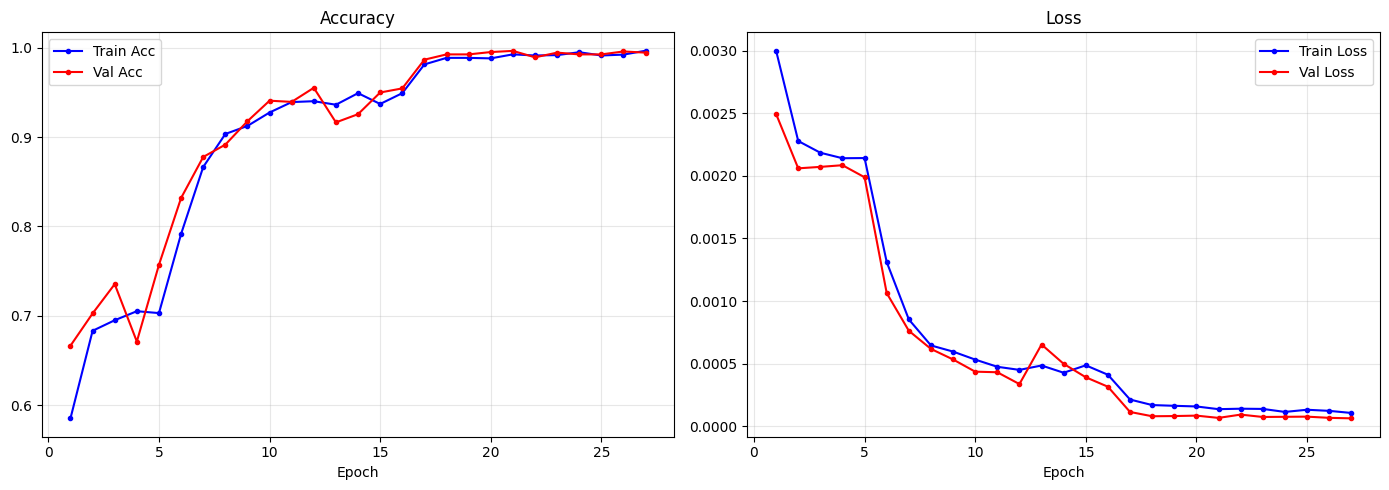

In [12]:
def plot_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_acc']) + 1)

    ax1.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=3)
    ax1.plot(epochs, history['val_acc'], 'r-o', label='Val Acc', markersize=3)
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=3)
    ax2.plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=3)
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_curves(history)

# Cell 9 — Test Set Evaluation (held-out, never seen during training)

Test Evaluation:   0%|          | 0/48 [00:00<?, ?it/s]


TEST SET ACCURACY: 0.9941 (99.41%)

                       precision    recall  f1-score   support

 Apple-Formalin-mixed       1.00      0.97      0.98        97
          Apple-Fresh       0.96      1.00      0.98       115
         Apple-Rotten       1.00      0.99      0.99        94
Banana-Formalin-mixed       1.00      1.00      1.00        99
         Banana-Fresh       1.00      1.00      1.00       113
        Banana-Rotten       1.00      1.00      1.00        95
 Grape-Formalin-mixed       1.00      0.99      0.99        91
          Grape-Fresh       0.97      0.99      0.98       116
         Grape-Rotten       1.00      0.98      0.99        94
 Mango-Formalin-mixed       0.99      1.00      0.99        92
          Mango-Fresh       1.00      1.00      1.00       115
         Mango-Rotten       1.00      0.99      0.99        94
Orange-Formalin-mixed       1.00      1.00      1.00        97
         Orange-Fresh       1.00      1.00      1.00       113
        Orange-Ro

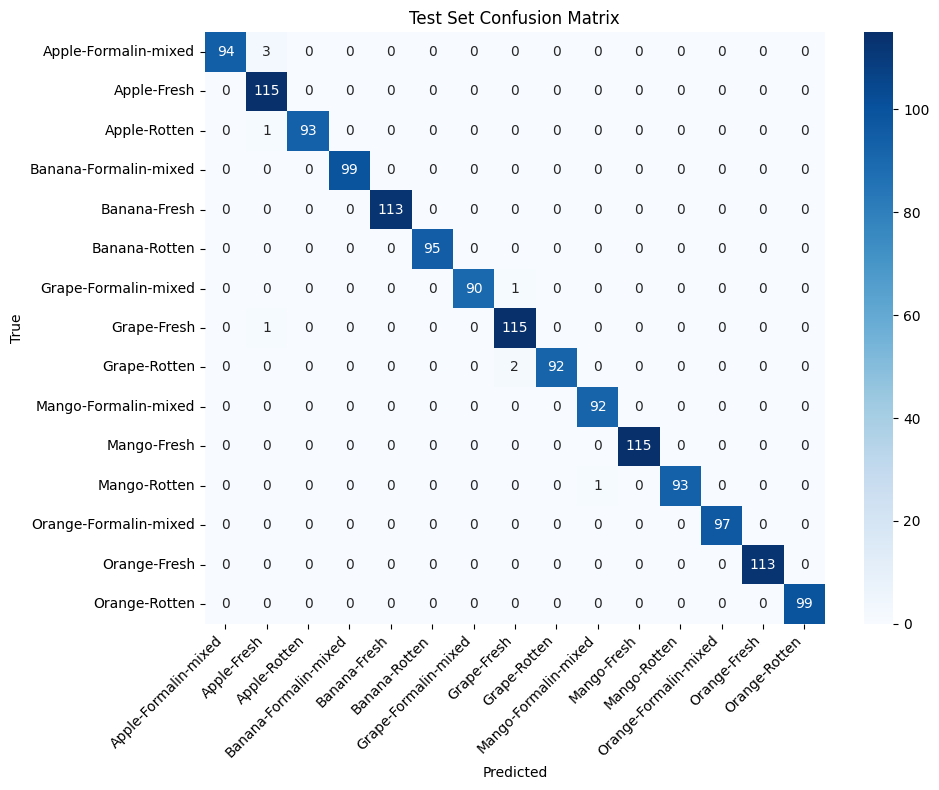

In [13]:
def evaluate_on_test(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Test Evaluation"):
            outputs = model(inputs.to(DEVICE))
            preds = outputs.argmax(dim=1).cpu()
            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    test_acc = np.mean(y_true == y_pred)
    print(f"\n{'='*50}")
    print(f"TEST SET ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"{'='*50}\n")

    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Test Set Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return test_acc, y_true, y_pred


test_acc, y_true, y_pred = evaluate_on_test(model, test_loader, full_dataset.classes)

# Cell 9b — Confusion Pair Analysis (Formalin ↔ Rotten diagnostic)
#
Prints the top-10 most confused class pairs. If Formalin ↔ Rotten pairs
dominate this list, the PairAwareCrossEntropy penalty (or additional
techniques like higher-resolution training or attention modules) should
be considered.

In [14]:
def analyze_confusion_pairs(y_true, y_pred, class_names, top_k=10):
    cm = confusion_matrix(y_true, y_pred)
    n = len(class_names)
    confusions = []
    for i in range(n):
        for j in range(n):
            if i != j and cm[i][j] > 0:
                confusions.append((cm[i][j], class_names[i], class_names[j]))

    confusions.sort(reverse=True)
    print(f"\nTop {top_k} confusion pairs (True → Predicted):")
    print("-" * 60)
    formalin_rotten_count = 0
    for count, true, pred in confusions[:top_k]:
        cond_true = true.rsplit('-', 1)[1]
        cond_pred = pred.rsplit('-', 1)[1]
        is_fr = {cond_true, cond_pred} == {'Formalin-mixed', 'Rotten'}
        marker = "  ⚠️ FORMALIN↔ROTTEN" if is_fr else ""
        if is_fr:
            formalin_rotten_count += count
        print(f"  {true:30s} → {pred:30s}: {count}{marker}")

    total_errors = (np.array(y_true) != np.array(y_pred)).sum()
    if total_errors > 0:
        fr_pct = 100 * formalin_rotten_count / total_errors
        print(f"\nFormalin↔Rotten confusion accounts for "
              f"{formalin_rotten_count}/{total_errors} errors ({fr_pct:.1f}%)")
        if fr_pct > 30:
            print("→ Formalin↔Rotten confusion is a significant issue.")
            print("  Consider: (1) higher input resolution, (2) attention modules,")
            print("  (3) hierarchical two-stage classifier, or (4) more training data.")
        else:
            print("→ Formalin↔Rotten confusion is not the dominant error mode.")


analyze_confusion_pairs(y_true, y_pred, full_dataset.classes, top_k=10)


Top 10 confusion pairs (True → Predicted):
------------------------------------------------------------
  Apple-Formalin-mixed           → Apple-Fresh                   : 3
  Grape-Rotten                   → Grape-Fresh                   : 2
  Mango-Rotten                   → Mango-Formalin-mixed          : 1
  Grape-Fresh                    → Apple-Fresh                   : 1
  Grape-Formalin-mixed           → Grape-Fresh                   : 1
  Apple-Rotten                   → Apple-Fresh                   : 1

Formalin↔Rotten confusion accounts for 0/9 errors (0.0%)
→ Formalin↔Rotten confusion is not the dominant error mode.


# Cell 10 — Stratified K-Fold Cross-Validation
#
K-Fold gives a more robust performance estimate by training on different data splits.
We use it for evaluation only — the final deployed model is still trained on the
full train+val set and evaluated on the held-out test set.

In [18]:
def kfold_evaluate(dataset, n_splits=5, num_epochs=15, patience=4):
    """
    Run stratified K-fold CV. Returns per-fold accuracies.
    Uses the full dataset minus the held-out test set.
    """
    # Combine train + val indices (test stays held out)
    combined_idx = np.concatenate([train_idx, val_idx])
    combined_labels = labels[combined_idx]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_accs = []

    for fold, (fold_train_rel, fold_val_rel) in enumerate(
            skf.split(np.zeros(len(combined_idx)), combined_labels)):

        print(f"\n{'='*55}")
        print(f"FOLD {fold+1}/{n_splits}")
        print(f"{'='*55}")

        fold_train_idx = combined_idx[fold_train_rel]
        fold_val_idx = combined_idx[fold_val_rel]

        fold_train = TransformedSubset(full_dataset, fold_train_idx, train_transform)
        fold_val = TransformedSubset(full_dataset, fold_val_idx, val_transform)

        # Weighted sampler for this fold's training set
        fold_train_labels = np.array(fold_train.targets)
        fold_class_counts = np.array([
            max(np.sum(fold_train_labels == c), 1) for c in range(NUM_CLASSES)
        ])
        fold_class_weights = 1.0 / fold_class_counts
        fold_sample_weights = torch.tensor(
            [fold_class_weights[t] for t in fold_train_labels], dtype=torch.double
        )
        fold_sampler = WeightedRandomSampler(fold_sample_weights, len(fold_sample_weights))

        fold_train_loader = DataLoader(fold_train, batch_size=BATCH_SIZE,
                                       sampler=fold_sampler, num_workers=0, pin_memory=True)
        fold_val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE,
                                     shuffle=False, num_workers=0, pin_memory=True)

        # Fresh model per fold
        fold_model = build_mobilenet(NUM_CLASSES)

        fold_criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(fold_class_weights, dtype=torch.float).to(DEVICE)
        )

        # Phase 1: head only
        fold_model, _ = train_model(
            fold_model, fold_train_loader, fold_val_loader, fold_criterion,
            num_epochs=3, patience=3, lr_head=1e-3, lr_backbone=None,
            phase_name=f"[F{fold+1}-P1]"
        )

        # Phase 2: full unfreeze
        for p in fold_model.features.parameters():
            p.requires_grad = True

        fold_model, fold_hist = train_model(
            fold_model, fold_train_loader, fold_val_loader, fold_criterion,
            num_epochs=num_epochs, patience=patience,
            lr_head=1e-3, lr_backbone=1e-4,
            phase_name=f"[F{fold+1}-P2]"
        )

        fold_best_acc = max(fold_hist['val_acc']) if fold_hist['val_acc'] else 0.0
        fold_accs.append(fold_best_acc)
        print(f"\nFold {fold+1} best val accuracy: {fold_best_acc:.4f}")

        # Free GPU memory
        del fold_model
        torch.cuda.empty_cache()

    # Summary
    print(f"\n{'='*55}")
    print(f"K-FOLD CROSS-VALIDATION RESULTS ({n_splits} folds)")
    print(f"{'='*55}")
    for i, acc in enumerate(fold_accs):
        print(f"  Fold {i+1}: {acc:.4f}")
    print(f"\n  Mean:  {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")
    print(f"{'='*55}")

    return fold_accs


# Run K-Fold (set n_splits=5 for standard 5-fold CV)
# This takes ~5× longer than single training — uncomment when ready
# fold_accs = kfold_evaluate(full_dataset, n_splits=5, num_epochs=15, patience=4)

# Cell 11 — Grad-CAM Explainability

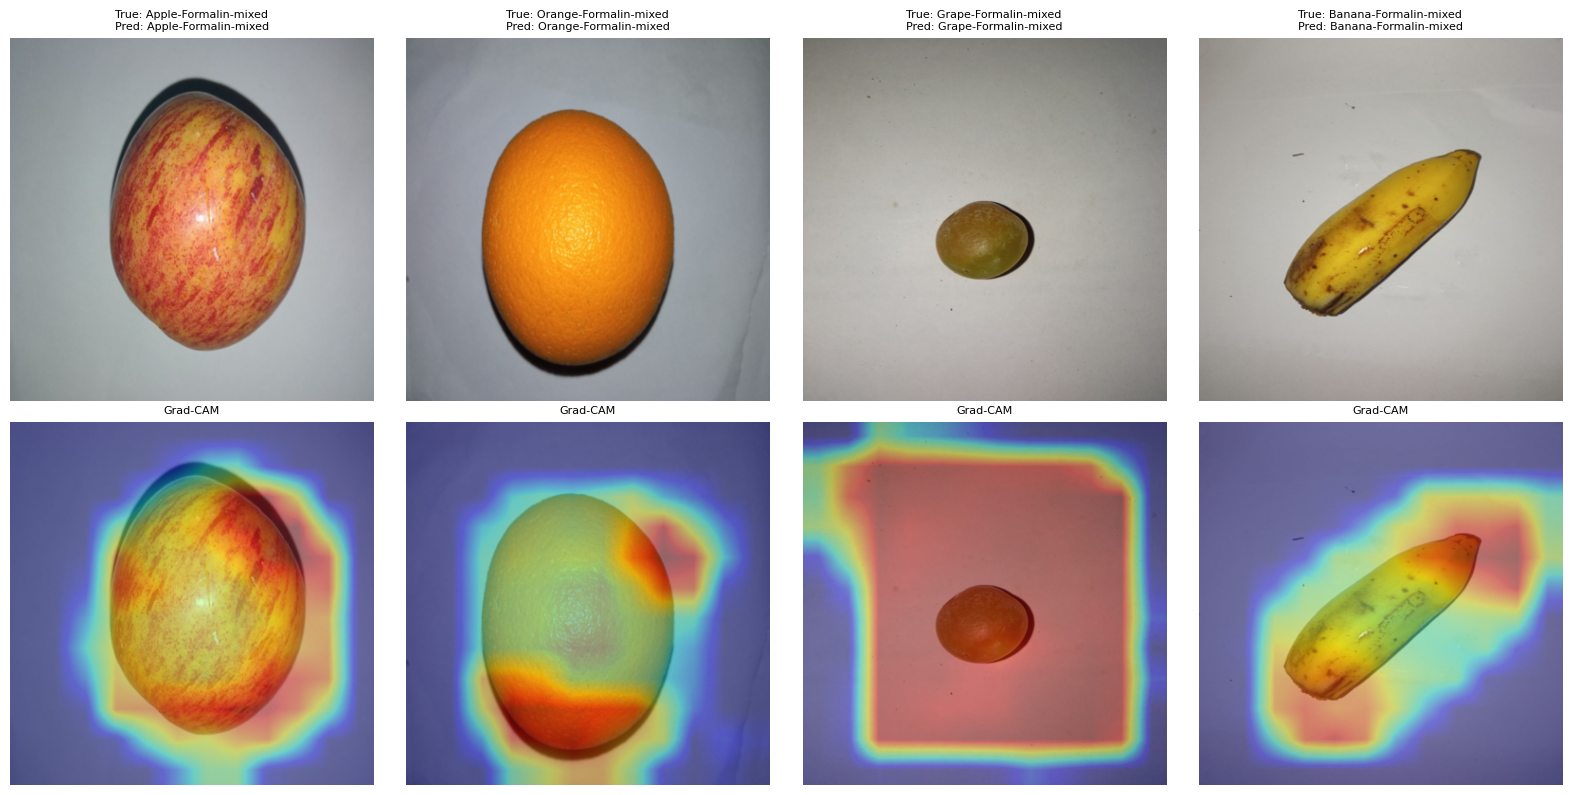

In [19]:
class GradCAM:
    """Grad-CAM for MobileNetV2. Targets features[-1] (last conv block)."""

    def __init__(self, model):
        self.model = model
        self.target_layer = model.features[-1]
        self.gradients = None
        self.activations = None
        self._fh = self.target_layer.register_forward_hook(self._save_activation)
        self._bh = self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear',
                            align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

    def cleanup(self):
        self._fh.remove()
        self._bh.remove()


def show_gradcam_samples(model, dataset, class_names, n=4):
    """Show Grad-CAM heatmaps for random samples."""
    grad_cam = GradCAM(model)
    indices = np.random.choice(len(dataset), n, replace=False)

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

    for col, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        input_t = img_tensor.unsqueeze(0).to(DEVICE)

        cam, pred_class = grad_cam.generate(input_t)

        # Denormalize for display
        img_display = img_tensor.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = (img_display * std + mean).clip(0, 1)

        axes[0, col].imshow(img_display)
        axes[0, col].set_title(f"True: {class_names[label]}\nPred: {class_names[pred_class]}",
                                fontsize=8)
        axes[0, col].axis('off')

        axes[1, col].imshow(img_display)
        axes[1, col].imshow(cam, cmap='jet', alpha=0.4)
        axes[1, col].set_title("Grad-CAM", fontsize=8)
        axes[1, col].axis('off')

    grad_cam.cleanup()
    plt.tight_layout()
    plt.show()


show_gradcam_samples(model, val_data, full_dataset.classes, n=4)

# Cell 12 — Export for Mobile
#
Save PyTorch + ONNX + class map for mobile deployment.

In [20]:
import json

EXPORT_DIR = "mobile_model"
os.makedirs(EXPORT_DIR, exist_ok=True)
model.eval()

# NOTE ON RESOLUTION: Training uses IMG_SIZE (384 by default) to help distinguish
# formalin (uniform coating) from rot (localized spots). For mobile, 384×384 is ~3×
# slower than 224×224. If mobile latency matters, either quantize aggressively at 384,
# or export a 224×224 version and accept a small accuracy drop.

# PyTorch checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': full_dataset.classes,
    'input_size': IMG_SIZE,
}, os.path.join(EXPORT_DIR, 'mobilenet_fruit_condition.pth'))

# ONNX export
try:
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    onnx_path = os.path.join(EXPORT_DIR, 'mobilenet_fruit_condition.onnx')
    torch.onnx.export(
        model, dummy, onnx_path,
        input_names=['image'], output_names=['prediction'],
        dynamic_axes={'image': {0: 'batch'}, 'prediction': {0: 'batch'}},
        opset_version=13
    )
    size_mb = os.path.getsize(onnx_path) / 1024 / 1024
    print(f"ONNX exported: {onnx_path} ({size_mb:.1f} MB)")
except Exception as e:
    print(f"ONNX export skipped: {e}")

# Class map
with open(os.path.join(EXPORT_DIR, 'class_map.json'), 'w') as f:
    json.dump({str(i): c for i, c in enumerate(full_dataset.classes)}, f, indent=2)

# Runtime config (no CLAHE — preprocessing on mobile is just resize + normalize)
with open(os.path.join(EXPORT_DIR, 'runtime_config.json'), 'w') as f:
    json.dump({
        'confidence_threshold': 0.60,
        'ambiguity_gap': 0.10,
        'input_size': IMG_SIZE,
        'normalize_mean': [0.485, 0.456, 0.406],
        'normalize_std': [0.229, 0.224, 0.225],
        'preprocessing': 'resize + normalize only (no CLAHE)',
    }, f, indent=2)

print(f"Mobile package saved to {EXPORT_DIR}/: {os.listdir(EXPORT_DIR)}")


# ═══════════════════════════════════════════════════════════════════════
#  NEW CELLS 13–17: MULTI-FRUIT DETECTION, NON-FRUIT REJECTION,
#                   QUALITY-AWARE CONFIDENCE GATING
# ═══════════════════════════════════════════════════════════════════════
#
#  Architecture (two-stage pipeline):
#
#    Input Image
#         │
#    ┌────▼────────────────────────┐
#    │  Stage 0: Image Quality     │  blur / dark / low-res / corrupt
#    │  Assessment                 │──▶ REJECT with reasons
#    └────┬────────────────────────┘
#         │ passes
#    ┌────▼────────────────────────┐
#    │  Stage 1: YOLOv8 Object     │  localize every object in frame
#    │  Detection                  │  (handles multi-fruit + non-fruit)
#    └────┬────────────────────────┘
#         │ per crop
#    ┌────▼────────────────────────┐
#    │  Stage 2: MobileNetV2       │  existing 15-class classifier
#    │  Fruit Classifier           │  runs on each cropped region
#    └────┬────────────────────────┘
#         │
#    ┌────▼────────────────────────┐
#    │  Stage 3: Confidence Gate   │  softmax, top-2 gap, entropy
#    │  + Rejection Engine         │──▶ fruit / non-fruit / uncertain
#    └────┬────────────────────────┘
#         │
#    ┌────▼────────────────────────┐
#    │  Visualization              │  boxes, Grad-CAM, rejection
#    │  + Explanation              │  reasons, confidence bars
#    └─────────────────────────────┘
#
#  Everything below is ADDITIVE — Cells 0–12 are untouched.
# ═══════════════════════════════════════════════════════════════════════

ONNX export skipped: No module named 'onnxscript'
Mobile package saved to mobile_model/: ['runtime_config.json', 'class_map.json', 'mobilenet_fruit_condition.pth']


# Cell 13 — Image Quality Assessment
#
Before detection/classification, check whether the image is even
processable. Blurry, too dark, overexposed, tiny, or corrupted images
are flagged with *specific* human-readable reasons so the user knows
**why** the model refused to make a prediction.

In [21]:
class ImageQualityAssessor:
    """
    Multi-check image quality gate.

    Checks (all configurable):
      1. Blur          — Laplacian variance (lower → blurrier)
      2. Brightness    — mean pixel intensity (too low / too high)
      3. Contrast      — pixel-intensity std  (too uniform)
      4. Resolution    — min(H, W) in pixels
      5. Aspect ratio  — extreme ratios often mean corrupt / banner images
      6. Color variety — near-grayscale images lose the colour cues
                         that distinguish formalin from rot

    Returns a dict with 'passed', 'issues' (list[str]), and 'metrics'.
    Severity levels: HARD issues block processing; SOFT issues only warn.
    """

    def __init__(self,
                 blur_threshold=80.0,
                 brightness_low=30,
                 brightness_high=240,
                 contrast_min=20.0,
                 min_resolution=64,
                 max_aspect_ratio=5.0,
                 color_std_min=10.0):
        self.blur_threshold   = blur_threshold
        self.brightness_low   = brightness_low
        self.brightness_high  = brightness_high
        self.contrast_min     = contrast_min
        self.min_resolution   = min_resolution
        self.max_aspect_ratio = max_aspect_ratio
        self.color_std_min    = color_std_min

    def assess(self, image):
        """
        Args:
            image: PIL.Image (RGB) or numpy array (H, W, 3).
        Returns:
            dict  →  passed (bool), issues (list[str]),
                     hard_fail (bool), metrics (dict)
        """
        if isinstance(image, Image.Image):
            img_np = np.array(image)
        else:
            img_np = image.copy()

        issues    = []
        hard_fail = False
        metrics   = {}

        h, w = img_np.shape[:2]
        metrics['height'] = h
        metrics['width']  = w

        # ── Resolution (HARD) ───────────────────────────────────────
        if min(h, w) < self.min_resolution:
            issues.append(
                f"[HARD] Resolution too low: {w}×{h}px "
                f"(need ≥{self.min_resolution}px on shortest side)"
            )
            hard_fail = True

        # ── Aspect ratio (HARD) ─────────────────────────────────────
        aspect = max(h, w) / max(min(h, w), 1)
        metrics['aspect_ratio'] = round(aspect, 2)
        if aspect > self.max_aspect_ratio:
            issues.append(
                f"[HARD] Extreme aspect ratio {aspect:.1f}:1 — "
                f"likely a banner/strip, not a fruit photo"
            )
            hard_fail = True

        # ── Convert to grayscale ────────────────────────────────────
        if len(img_np.shape) == 3:
            gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_np

        # ── Blur (SOFT — warn but let YOLO try) ────────────────────
        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        metrics['blur_score'] = round(laplacian_var, 2)
        if laplacian_var < self.blur_threshold:
            severity = "HARD" if laplacian_var < self.blur_threshold / 3 else "SOFT"
            issues.append(
                f"[{severity}] Image is blurry — sharpness "
                f"{laplacian_var:.1f} (need ≥{self.blur_threshold:.0f}). "
                f"Edges are too soft for reliable classification."
            )
            if severity == "HARD":
                hard_fail = True

        # ── Brightness (SOFT / HARD depending on severity) ─────────
        mean_b = float(gray.mean())
        metrics['brightness'] = round(mean_b, 2)
        if mean_b < self.brightness_low:
            severity = "HARD" if mean_b < 15 else "SOFT"
            issues.append(
                f"[{severity}] Image is too dark — brightness "
                f"{mean_b:.0f}/255 (need ≥{self.brightness_low}). "
                f"Try with better lighting."
            )
            if severity == "HARD":
                hard_fail = True
        elif mean_b > self.brightness_high:
            severity = "HARD" if mean_b > 250 else "SOFT"
            issues.append(
                f"[{severity}] Image is overexposed — brightness "
                f"{mean_b:.0f}/255 (need ≤{self.brightness_high}). "
                f"Colors are washed out."
            )
            if severity == "HARD":
                hard_fail = True

        # ── Contrast (SOFT) ─────────────────────────────────────────
        contrast = float(gray.std())
        metrics['contrast'] = round(contrast, 2)
        if contrast < self.contrast_min:
            issues.append(
                f"[SOFT] Very low contrast (std={contrast:.1f}, "
                f"need ≥{self.contrast_min:.0f}). Object boundaries "
                f"may not be distinguishable."
            )

        # ── Color variety (SOFT) — important for formalin detection ─
        if len(img_np.shape) == 3 and img_np.shape[2] == 3:
            color_std = float(img_np.std(axis=(0, 1)).mean())
            metrics['color_variety'] = round(color_std, 2)
            if color_std < self.color_std_min:
                issues.append(
                    f"[SOFT] Image is nearly monochrome "
                    f"(colour std={color_std:.1f}). Formalin vs. rot "
                    f"detection relies on colour cues."
                )

        return {
            'passed':    len(issues) == 0,
            'hard_fail': hard_fail,
            'issues':    issues,
            'metrics':   metrics,
        }


quality_assessor = ImageQualityAssessor()
print("✅ Image quality assessor ready.")

✅ Image quality assessor ready.


# Cell 14 — Confidence Analysis Engine
#
After the MobileNetV2 classifier produces logits, this module decides
whether the prediction is **trustworthy** using three complementary
signals:
#
| Signal | What it catches |
|--------|-----------------|
| Max-softmax < threshold | Non-fruit objects (very low confidence on every class) |
| Top-1 – Top-2 gap too small | Ambiguous: model torn between two classes |
| Normalised entropy too high | Confused across many classes at once |
#
The result is a verdict: `confident`, `uncertain`, or `non_fruit`,
plus human-readable **reasons** explaining why.

In [22]:
class ConfidenceAnalyzer:
    """
    Analyzes classifier softmax output and issues a confidence verdict.

    Thresholds
    ----------
    confidence_threshold : float   — min P(top-1) to be "confident"
    ambiguity_gap        : float   — min gap between top-1 and top-2
    entropy_max          : float   — max normalised entropy (0–1)
    non_fruit_threshold  : float   — below this → almost certainly not a fruit
    """

    def __init__(self, class_names, *,
                 confidence_threshold=0.50,
                 ambiguity_gap=0.15,
                 entropy_max=0.60,
                 non_fruit_threshold=0.25):
        self.class_names           = class_names
        self.num_classes           = len(class_names)
        self.confidence_threshold  = confidence_threshold
        self.ambiguity_gap         = ambiguity_gap
        self.entropy_max           = entropy_max
        self.non_fruit_threshold   = non_fruit_threshold

    def analyze(self, logits):
        """
        Args:
            logits: Tensor (1, C) raw model output.
        Returns:
            dict → status, predicted_class, confidence, top_k, gap,
                   entropy, reasons, probabilities
        """
        probs = F.softmax(logits, dim=1).squeeze().detach().cpu().numpy()

        sorted_idx = np.argsort(probs)[::-1]
        top1_prob  = float(probs[sorted_idx[0]])
        top2_prob  = float(probs[sorted_idx[1]])
        gap        = top1_prob - top2_prob

        # Normalised entropy  (0 = certain, 1 = uniform)
        entropy      = -np.sum(probs * np.log(probs + 1e-10))
        max_entropy  = np.log(self.num_classes)
        norm_entropy = float(entropy / max_entropy)

        top_k = [(self.class_names[i], float(probs[i]))
                 for i in sorted_idx[:5]]

        predicted_class = self.class_names[sorted_idx[0]]
        reasons = []

        # ── Decision tree ───────────────────────────────────────────
        # 1) Very low confidence → not a fruit
        if top1_prob < self.non_fruit_threshold:
            status = 'non_fruit'
            reasons.append(
                f"Highest probability is only {top1_prob:.1%} "
                f"(need ≥{self.non_fruit_threshold:.0%}) — "
                f"this does not look like any known fruit."
            )

        # 2) Below acceptance threshold
        elif top1_prob < self.confidence_threshold:
            status = 'uncertain'
            reasons.append(
                f"Low confidence: {top1_prob:.1%} for "
                f"'{predicted_class}' "
                f"(need ≥{self.confidence_threshold:.0%})."
            )

        # 3) Top-2 gap too small → model torn between two classes
        elif gap < self.ambiguity_gap:
            status = 'uncertain'
            reasons.append(
                f"Ambiguous: '{top_k[0][0]}' ({top_k[0][1]:.1%}) vs "
                f"'{top_k[1][0]}' ({top_k[1][1]:.1%}) — gap is only "
                f"{gap:.1%} (need ≥{self.ambiguity_gap:.0%})."
            )
            # Flag dangerous Formalin ↔ Rotten confusion specifically
            conds = set()
            for name, _ in top_k[:2]:
                conds.add(name.rsplit('-', 1)[-1])
            if conds == {'Formalin-mixed', 'Rotten'}:
                reasons.append(
                    "⚠️ SAFETY: model is confused between Formalin "
                    "and Rotten — this is the most dangerous error. "
                    "Manual inspection recommended."
                )

        # 4) High entropy → spread across many classes
        elif norm_entropy > self.entropy_max:
            status = 'uncertain'
            top3_str = ', '.join(f"'{n}' {p:.0%}" for n, p in top_k[:3])
            reasons.append(
                f"High confusion across multiple classes "
                f"(entropy={norm_entropy:.2f}): {top3_str}."
            )

        # 5) All checks passed
        else:
            status = 'confident'

        return {
            'status':          status,
            'predicted_class': predicted_class,
            'confidence':      top1_prob,
            'top_k':           top_k,
            'gap':             gap,
            'entropy':         norm_entropy,
            'reasons':         reasons,
            'probabilities':   probs,
        }


confidence_analyzer = ConfidenceAnalyzer(full_dataset.classes)
print("✅ Confidence analyzer ready.")

✅ Confidence analyzer ready.


# Cell 15 — YOLOv8 Detection + Full Multi-Fruit Pipeline
#
**Why YOLOv8?**  The existing MobileNetV2 is a *classifier* — it
assumes exactly one centred fruit fills the frame.  YOLO is an *object
detector* — it draws bounding boxes around every object in a photo,
even when there are many.
#
**Pipeline:**
  1. YOLOv8-nano finds all objects (bounding boxes).
  2. Each box is cropped, padded for context, and sent through the
     trained MobileNetV2 classifier.
  3. The ConfidenceAnalyzer decides: **fruit** (confident), **non-fruit**
     (very low confidence → the crop doesn't match any fruit class), or
     **uncertain** (blurry crop, ambiguous, high entropy → model says "I
     can't tell" and explains why).
  4. If YOLO finds nothing at all, the whole image is tried as a single
     crop (backward-compatible with single-fruit photos).

In [23]:
# ── Install ultralytics if needed (Kaggle-compatible) ───────────────
import subprocess, importlib
if importlib.util.find_spec("ultralytics") is None:
    subprocess.check_call(
        ['pip', 'install', 'ultralytics', '-q', '--no-deps']
    )
    # ultralytics needs a couple of light deps that Kaggle already has;
    # --no-deps avoids re-downloading torch.  If a dep is missing,
    # remove --no-deps.

from ultralytics import YOLO as UltralyticsYOLO

# ── Load pretrained YOLOv8-nano (~6 MB, very fast) ──────────────────
yolo_detector = UltralyticsYOLO('yolov8n.pt')   # auto-downloads once
COCO_NAMES    = yolo_detector.names              # {0:'person', …}

# COCO IDs that map to real fruit
COCO_FRUIT_IDS = {46: 'banana', 47: 'apple', 49: 'orange'}

print(f"✅ YOLOv8-nano loaded ({len(COCO_NAMES)} COCO classes).")
print(f"   Known fruit IDs in COCO: {COCO_FRUIT_IDS}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8-nano loaded (80 COCO classes).
   Known fruit IDs in COCO: {46: 'banana', 47: 'apple', 49: 'orange'}


In [24]:
class FruitDetectionPipeline:
    """
    End-to-end pipeline: quality → detect → classify → gate → explain.

    Handles
    -------
    - Single fruit photo          (backward-compatible)
    - Multiple fruits in one shot (YOLO finds each one)
    - Non-fruit objects           (person, car… flagged with COCO label)
    - Unclassifiable inputs       (blur, darkness, ambiguity → explained)
    """

    def __init__(self, classifier, yolo, class_names,
                 quality_assessor, confidence_analyzer,
                 val_transform, device=DEVICE,
                 yolo_conf=0.25, min_crop_px=32, crop_pad=0.12):
        """
        Args:
            classifier:          trained MobileNetV2  (existing `model`)
            yolo:                UltralyticsYOLO instance
            class_names:         list[str] — the 15 fruit×condition names
            quality_assessor:    ImageQualityAssessor
            confidence_analyzer: ConfidenceAnalyzer
            val_transform:       torchvision transform (resize + norm)
            yolo_conf:           YOLO detection confidence floor
            min_crop_px:         ignore detections smaller than this
            crop_pad:            fractional padding around each crop
        """
        self.classifier  = classifier
        self.yolo        = yolo
        self.class_names = class_names
        self.quality     = quality_assessor
        self.confidence  = confidence_analyzer
        self.transform   = val_transform
        self.device      = device
        self.yolo_conf   = yolo_conf
        self.min_crop    = min_crop_px
        self.crop_pad    = crop_pad

    # ── internal: classify a single PIL crop ────────────────────────
    def _classify_crop(self, crop_pil):
        """Run one crop through classifier → confidence analysis."""
        inp = self.transform(crop_pil).unsqueeze(0).to(self.device)

        self.classifier.eval()
        with torch.no_grad():
            logits = self.classifier(inp)

        return self.confidence.analyze(logits)

    # ── internal: Grad-CAM for a single crop (needs grad) ──────────
    def _gradcam_crop(self, crop_pil, target_class_idx):
        """Generate Grad-CAM heatmap for a single crop."""
        gc = GradCAM(self.classifier)          # fresh hooks
        try:
            inp = self.transform(crop_pil).unsqueeze(0).to(self.device)
            cam, _ = gc.generate(inp, target_class=target_class_idx)
            return cam
        finally:
            gc.cleanup()                       # always remove hooks

    # ── internal: quality-check a crop region ───────────────────────
    def _crop_quality(self, crop_np):
        """Quick quality check on a detection crop."""
        issues = []
        gray = cv2.cvtColor(crop_np, cv2.COLOR_RGB2GRAY) \
               if len(crop_np.shape) == 3 else crop_np
        lap = cv2.Laplacian(gray, cv2.CV_64F).var()
        if lap < 40:                           # tighter than whole-image
            issues.append(
                f"Crop is blurry (sharpness {lap:.0f}, need ≥40)"
            )
        mean_b = float(gray.mean())
        if mean_b < 20:
            issues.append(f"Crop is too dark (brightness {mean_b:.0f}/255)")
        elif mean_b > 245:
            issues.append(
                f"Crop is overexposed (brightness {mean_b:.0f}/255)"
            )
        return issues

    # ── public API ──────────────────────────────────────────────────
    def detect(self, image_input):
        """
        Run the full pipeline.

        Args:
            image_input: file path (str/Path) or PIL.Image

        Returns:
            dict with keys:
              status      — 'success' | 'quality_fail' | 'no_fruit'
              quality     — whole-image quality dict
              detections  — list of per-object dicts
              summary     — human-readable multi-line string
              image       — original PIL Image (or None if corrupt)
        """
        # ── Load image ──────────────────────────────────────────────
        if isinstance(image_input, (str, os.PathLike)):
            try:
                image = Image.open(image_input).convert('RGB')
            except Exception as e:
                return self._fail(
                    f"Cannot open file: {e}",
                    quality={'passed': False, 'hard_fail': True,
                             'issues': [f"[HARD] File unreadable: {e}"],
                             'metrics': {}},
                )
        elif isinstance(image_input, np.ndarray):
            image = Image.fromarray(image_input)
        else:
            image = image_input.convert('RGB')

        img_np = np.array(image)

        # ── Stage 0: whole-image quality ────────────────────────────
        quality = self.quality.assess(image)

        if quality['hard_fail']:
            return self._fail(
                "Image quality too low for reliable detection",
                quality=quality, image=image,
            )

        # ── Stage 1: YOLO object detection ──────────────────────────
        yolo_res = self.yolo(img_np, conf=self.yolo_conf, verbose=False)
        boxes    = yolo_res[0].boxes
        H, W     = img_np.shape[:2]

        detections = []

        if len(boxes) == 0:
            # No YOLO hits → treat whole image as one candidate
            detections.append(
                self._process_region(
                    image, img_np,
                    bbox=(0, 0, W, H),
                    coco_cls=None, coco_conf=None,
                    source='whole_image',
                )
            )
        else:
            for i in range(len(boxes)):
                box       = boxes[i]
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                coco_id   = int(box.cls[0])
                coco_conf = float(box.conf[0])
                coco_name = COCO_NAMES.get(coco_id, f"object_{coco_id}")

                # Skip tiny detections
                if (x2 - x1) < self.min_crop or (y2 - y1) < self.min_crop:
                    continue

                detections.append(
                    self._process_region(
                        image, img_np,
                        bbox=(int(x1), int(y1), int(x2), int(y2)),
                        coco_cls=coco_name, coco_conf=coco_conf,
                        coco_id=coco_id, source='yolo',
                    )
                )

            # If YOLO only found non-fruit objects and missed actual
            # fruits (grapes/mangos aren't in COCO), also try the
            # whole image as a fallback
            fruit_found = any(d['is_fruit'] for d in detections)
            all_coco_non_fruit = all(
                d.get('coco_id') is not None and
                d['coco_id'] not in COCO_FRUIT_IDS
                for d in detections
            )
            if not fruit_found and all_coco_non_fruit:
                fallback = self._process_region(
                    image, img_np,
                    bbox=(0, 0, W, H),
                    coco_cls=None, coco_conf=None,
                    source='fallback_whole',
                )
                if fallback['is_fruit']:
                    detections.append(fallback)

        # ── Build summary ───────────────────────────────────────────
        return self._build_result(detections, quality, image)

    # ── helpers ─────────────────────────────────────────────────────
    def _process_region(self, pil_img, img_np, bbox,
                        coco_cls, coco_conf,
                        coco_id=None, source='yolo'):
        """Crop, quality-check, classify, and confidence-gate one region."""
        x1, y1, x2, y2 = bbox
        H, W = img_np.shape[:2]

        # Pad crop for context
        cw, ch  = x2 - x1, y2 - y1
        px, py  = int(cw * self.crop_pad), int(ch * self.crop_pad)
        cx1     = max(0, x1 - px)
        cy1     = max(0, y1 - py)
        cx2     = min(W, x2 + px)
        cy2     = min(H, y2 + py)
        crop    = pil_img.crop((cx1, cy1, cx2, cy2))
        crop_np = img_np[cy1:cy2, cx1:cx2]

        # Per-crop quality
        crop_issues = self._crop_quality(crop_np)

        # Classify
        analysis = self._classify_crop(crop)

        # ── Decide: fruit / non-fruit / uncertain ───────────────────
        is_known_coco_fruit = (coco_id is not None and
                               coco_id in COCO_FRUIT_IDS)

        # Merge crop quality issues into reasons
        if crop_issues:
            analysis['reasons'] = crop_issues + analysis['reasons']
            # Downgrade to uncertain if crop quality is bad
            if analysis['status'] == 'confident':
                analysis['status'] = 'uncertain'

        status = analysis['status']

        if status == 'confident':
            is_fruit = True
            label    = (f"{analysis['predicted_class']} "
                        f"({analysis['confidence']:.0%})")
            message  = None
        elif status == 'non_fruit' and not is_known_coco_fruit:
            is_fruit = False
            obj_name = coco_cls or "unknown object"
            label    = f"Non-Fruit: {obj_name}"
            message  = (f"Detected '{obj_name}' — not a recognisable "
                        f"fruit.")
        else:
            # uncertain (or non_fruit for a COCO fruit → treat as uncertain)
            is_fruit = None
            label    = f"Uncertain: {analysis['predicted_class']}?"
            message  = ("Cannot classify this region confidently:\n" +
                        "\n".join(f"  • {r}" for r in analysis['reasons']))

        return {
            'bbox':           [x1, y1, x2, y2],
            'crop':           crop,
            'source':         source,
            'coco_class':     coco_cls,
            'coco_id':        coco_id,
            'coco_conf':      coco_conf,
            'classification': analysis,
            'is_fruit':       is_fruit,
            'label':          label,
            'message':        message,
        }

    @staticmethod
    def _fail(reason, quality=None, image=None):
        return {
            'status':     'quality_fail',
            'quality':    quality or {},
            'detections': [],
            'summary':    f"❌ {reason}\n" + (
                "\n".join(f"  • {i}" for i in quality.get('issues', []))
                if quality else ""
            ),
            'image':      image,
        }

    @staticmethod
    def _build_result(detections, quality, image):
        fruits    = [d for d in detections if d['is_fruit'] is True]
        non_fruit = [d for d in detections if d['is_fruit'] is False]
        uncertain = [d for d in detections if d['is_fruit'] is None]

        parts = []

        if fruits:
            parts.append(
                f"✅ {len(fruits)} fruit(s) detected:\n" +
                "\n".join(f"   {i+1}. {d['label']}"
                          for i, d in enumerate(fruits))
            )
        if non_fruit:
            parts.append(
                f"🚫 {len(non_fruit)} non-fruit object(s):\n" +
                "\n".join(f"   • {d['label']}" for d in non_fruit)
            )
        if uncertain:
            parts.append(
                f"⚠️  {len(uncertain)} region(s) could not be "
                f"classified:"
            )
            for d in uncertain:
                if d['message']:
                    parts.append(d['message'])

        if quality.get('issues'):
            soft = [i for i in quality['issues'] if '[SOFT]' in i]
            if soft:
                parts.append(
                    "⚠️  Image quality warnings:\n" +
                    "\n".join(f"  • {i}" for i in soft)
                )

        if not detections:
            parts.append("❌ No objects detected in the image.")

        overall = ('success' if fruits else
                   'no_fruit' if (non_fruit and not uncertain) else
                   'uncertain')

        return {
            'status':     overall,
            'quality':    quality,
            'detections': detections,
            'summary':    "\n".join(parts),
            'image':      image,
        }


# ── Instantiate the pipeline (uses existing `model` from Cell 6) ────
pipeline = FruitDetectionPipeline(
    classifier          = model,
    yolo                = yolo_detector,
    class_names         = full_dataset.classes,
    quality_assessor    = quality_assessor,
    confidence_analyzer = confidence_analyzer,
    val_transform       = val_transform,
    device              = DEVICE,
)
print("✅ FruitDetectionPipeline ready.")
print(f"   Classifier classes: {full_dataset.classes}")

✅ FruitDetectionPipeline ready.
   Classifier classes: ['Apple-Formalin-mixed', 'Apple-Fresh', 'Apple-Rotten', 'Banana-Formalin-mixed', 'Banana-Fresh', 'Banana-Rotten', 'Grape-Formalin-mixed', 'Grape-Fresh', 'Grape-Rotten', 'Mango-Formalin-mixed', 'Mango-Fresh', 'Mango-Rotten', 'Orange-Formalin-mixed', 'Orange-Fresh', 'Orange-Rotten']


# Cell 16 — Visualization: Boxes, Grad-CAM Explanations, Confidence
#
Three panels:
  1. **Annotated image** — bounding boxes colour-coded:
     green = fruit, red = non-fruit, amber = uncertain.
  2. **Confidence bars** — per-detection horizontal bar chart.
  3. **Rejection explanations** — for every uncertain / non-fruit crop:
     the crop itself, its Grad-CAM heatmap showing where the model
     looked, and the top-3 predictions with probabilities.

In [25]:
def _denorm(tensor_img):
    """Undo ImageNet normalisation for display."""
    img = tensor_img.permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + \
              np.array([0.485, 0.456, 0.406])
    return img.clip(0, 1)


COLOR_FRUIT     = (0,  180, 0)      # green
COLOR_NON_FRUIT = (220, 50, 50)     # red
COLOR_UNCERTAIN = (255, 190, 0)     # amber


def visualize_result(result, figsize=7):
    """
    Master visualisation for a pipeline result dict.

    Draws three figure groups:
      [A] Annotated image with bounding boxes
      [B] Per-detection confidence bar chart
      [C] Grad-CAM explanation for every non-confident detection
    """
    if result['image'] is None:
        print(result['summary'])
        return

    img_np     = np.array(result['image'])
    detections = result['detections']
    quality    = result.get('quality', {})

    # ═════════════════════════════════════════════════════════════════
    # [A] + [B]  — Annotated image  &  Confidence bars
    # ═════════════════════════════════════════════════════════════════
    has_bars = len(detections) > 0
    ncols    = 2 if has_bars else 1
    fig, axes = plt.subplots(1, ncols,
                             figsize=(figsize * ncols, figsize),
                             gridspec_kw={'width_ratios':
                                          [2, 1] if has_bars else [1]})
    if ncols == 1:
        axes = [axes]

    # ── [A] draw bounding boxes ─────────────────────────────────────
    annotated = img_np.copy()
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        if det['is_fruit'] is True:
            col = COLOR_FRUIT
        elif det['is_fruit'] is False:
            col = COLOR_NON_FRUIT
        else:
            col = COLOR_UNCERTAIN

        cv2.rectangle(annotated, (x1, y1), (x2, y2), col, 3)

        # Label banner
        label = det['label']
        fs = max(0.4, min(0.7, annotated.shape[1] / 800))
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX,
                                       fs, 1)
        cv2.rectangle(annotated,
                      (x1, max(y1 - th - 8, 0)),
                      (x1 + tw + 6, y1), col, -1)
        cv2.putText(annotated, label,
                    (x1 + 3, max(y1 - 4, th + 2)),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 255, 255), 1,
                    cv2.LINE_AA)

    axes[0].imshow(annotated)
    title = "Detection Results"
    if quality.get('issues'):
        title += "  ⚠️ quality warnings present"
    axes[0].set_title(title, fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # ── [B] confidence bars ─────────────────────────────────────────
    if has_bars:
        ax = axes[1]
        labels_bar, confs, bar_colors = [], [], []
        for i, det in enumerate(detections):
            cls   = det.get('classification', {})
            conf  = cls.get('confidence', 0)
            short = det['label']
            if len(short) > 28:
                short = short[:26] + '…'
            labels_bar.append(f"#{i+1} {short}")
            confs.append(conf)
            if det['is_fruit'] is True:
                bar_colors.append('#2ecc71')
            elif det['is_fruit'] is False:
                bar_colors.append('#e74c3c')
            else:
                bar_colors.append('#f39c12')

        y_pos = np.arange(len(labels_bar))
        ax.barh(y_pos, confs, color=bar_colors, height=0.55,
                edgecolor='white', linewidth=0.5)
        for yp, c in zip(y_pos, confs):
            ax.text(c + 0.02, yp, f"{c:.0%}", va='center', fontsize=8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels_bar, fontsize=8)
        ax.set_xlim(0, 1.15)
        ax.set_xlabel('Confidence', fontsize=10)
        ax.set_title('Per-Detection Confidence', fontsize=12,
                      fontweight='bold')
        ax.axvline(x=0.50, color='gray', ls='--', alpha=0.5,
                   label='Accept threshold')
        ax.axvline(x=0.25, color='red',  ls=':', alpha=0.4,
                   label='Non-fruit cutoff')
        ax.legend(fontsize=7, loc='lower right')
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # ═════════════════════════════════════════════════════════════════
    # [C]  Grad-CAM explanation for non-confident detections
    # ═════════════════════════════════════════════════════════════════
    problem_dets = [d for d in detections if d['is_fruit'] is not True]

    if not problem_dets:
        # All detections confident — nothing to explain
        print("\n" + "=" * 60)
        print("DETECTION SUMMARY")
        print("=" * 60)
        print(result['summary'])
        print("=" * 60)
        return

    n   = len(problem_dets)
    fig, axes = plt.subplots(3, max(n, 1),
                             figsize=(5 * max(n, 1), 14))
    if n == 1:
        axes = axes.reshape(3, 1)

    fig.suptitle("⚠️  Why These Detections Could Not Be Classified",
                 fontsize=14, fontweight='bold', y=1.01)

    for col, det in enumerate(problem_dets):
        cls  = det['classification']
        crop = det['crop']

        # Row 0 — original crop
        axes[0, col].imshow(crop)
        status_icon = "🚫" if det['is_fruit'] is False else "❓"
        axes[0, col].set_title(
            f"{status_icon} {det['label']}", fontsize=9,
            color='red' if det['is_fruit'] is False else '#CC7700')
        axes[0, col].axis('off')

        # Row 1 — Grad-CAM overlay
        pred_idx = full_dataset.class_to_idx.get(
            cls['predicted_class'], 0)
        try:
            cam = pipeline._gradcam_crop(crop, pred_idx)
            inp_display = _denorm(val_transform(crop))

            axes[1, col].imshow(inp_display)
            axes[1, col].imshow(cam, cmap='jet', alpha=0.45)
            axes[1, col].set_title("Grad-CAM: where model looked",
                                    fontsize=8)
        except Exception:
            axes[1, col].text(0.5, 0.5, "Grad-CAM\nunavailable",
                               ha='center', va='center', fontsize=10)
        axes[1, col].axis('off')

        # Row 2 — top-5 probability bar
        top5 = cls.get('top_k', [])[:5]
        if top5:
            names   = [t[0].replace('-', '\n', 1) for t in top5]
            probs_5 = [t[1] for t in top5]
            bcolors = ['#e74c3c' if p < 0.25 else
                       '#f39c12' if p < 0.50 else '#2ecc71'
                       for p in probs_5]
            bars = axes[2, col].barh(range(len(names)), probs_5,
                                      color=bcolors, height=0.6)
            axes[2, col].set_yticks(range(len(names)))
            axes[2, col].set_yticklabels(names, fontsize=6)
            axes[2, col].set_xlim(0, 1)
            axes[2, col].set_xlabel('Probability', fontsize=7)
            axes[2, col].invert_yaxis()
            axes[2, col].set_title("Top-5 predictions", fontsize=8)
        else:
            axes[2, col].axis('off')

    # Hide unused columns
    for col in range(n, axes.shape[1]):
        for row in range(3):
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    # ── Print full textual summary with reasons ─────────────────────
    print("\n" + "=" * 60)
    print("DETECTION SUMMARY")
    print("=" * 60)
    print(result['summary'])

    for i, det in enumerate(problem_dets):
        print(f"\n--- Detection #{i+1}: {det['label']} ---")
        if det['message']:
            print(det['message'])
        cls = det['classification']
        print(f"    Top predictions:")
        for name, prob in cls['top_k'][:5]:
            bar = '█' * int(prob * 30)
            print(f"      {name:30s}  {prob:6.1%}  {bar}")
    print("=" * 60)

# Cell 17 — Demo: Run the Pipeline
#
Three ways to use the pipeline:
#
```python
# 1. Single image file
result = pipeline.detect("path/to/photo.jpg")
visualize_result(result)
#
# 2. PIL Image object
from PIL import Image
img = Image.open("photo.jpg")
result = pipeline.detect(img)
visualize_result(result)
#
# 3. Batch of files
for path in glob.glob("test_images/*.jpg"):
    result = pipeline.detect(path)
    visualize_result(result)
```

PIPELINE DEMO — random test-set samples

────────────────────────────────────────────────────────────
Sample 1/4: 6150065028531862058.jpg
Ground truth: Mango-Rotten
────────────────────────────────────────────────────────────


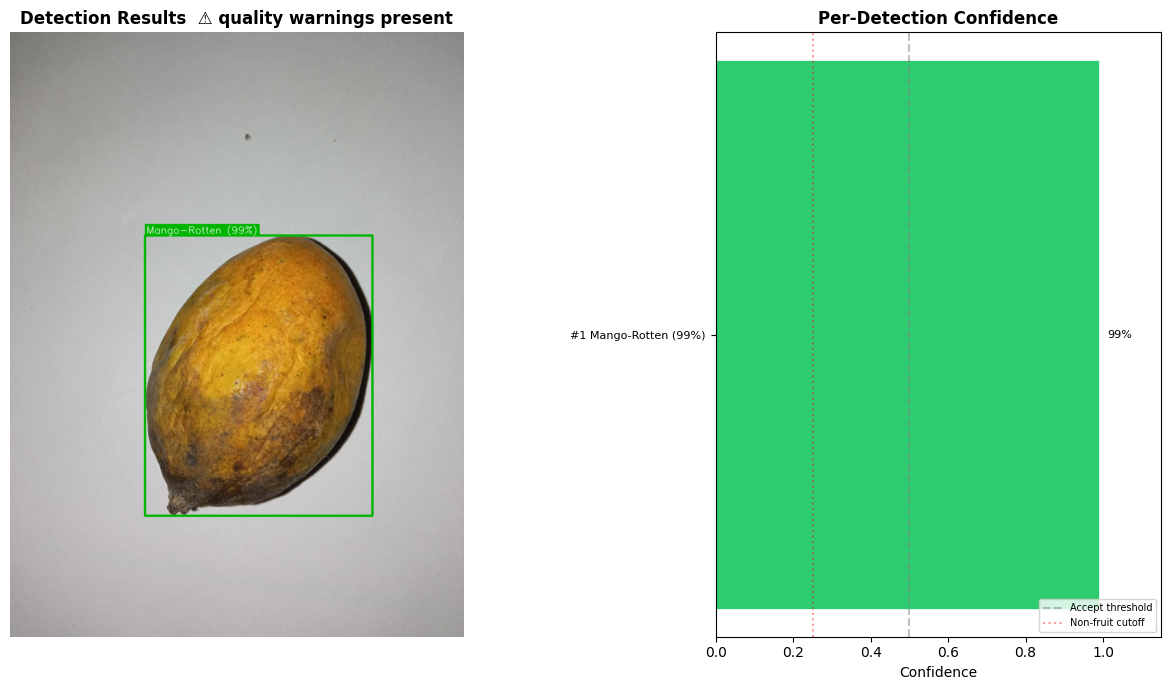


DETECTION SUMMARY
✅ 1 fruit(s) detected:
   1. Mango-Rotten (99%)
⚠️  Image quality warnings:
  • [SOFT] Image is blurry — sharpness 55.1 (need ≥80). Edges are too soft for reliable classification.

────────────────────────────────────────────────────────────
Sample 2/4: msg5170347760-63317.jpg
Ground truth: Grape-Fresh
────────────────────────────────────────────────────────────


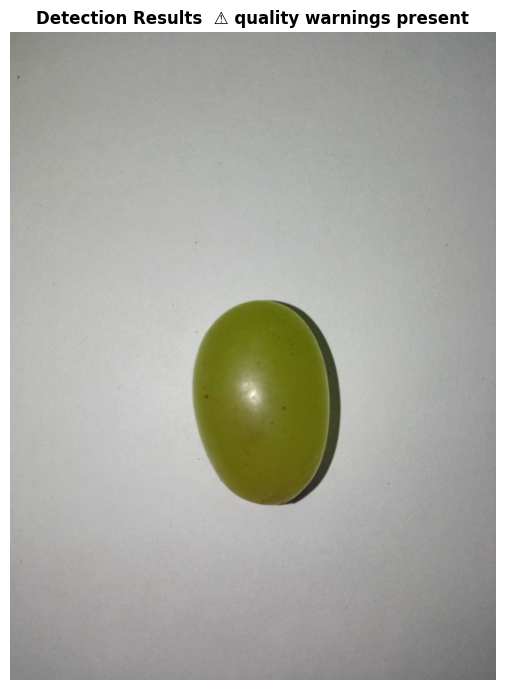


DETECTION SUMMARY
❌ Image quality too low for reliable detection
  • [HARD] Image is blurry — sharpness 15.5 (need ≥80). Edges are too soft for reliable classification.

────────────────────────────────────────────────────────────
Sample 3/4: msg5170347760-69241.jpg
Ground truth: Orange-Fresh
────────────────────────────────────────────────────────────


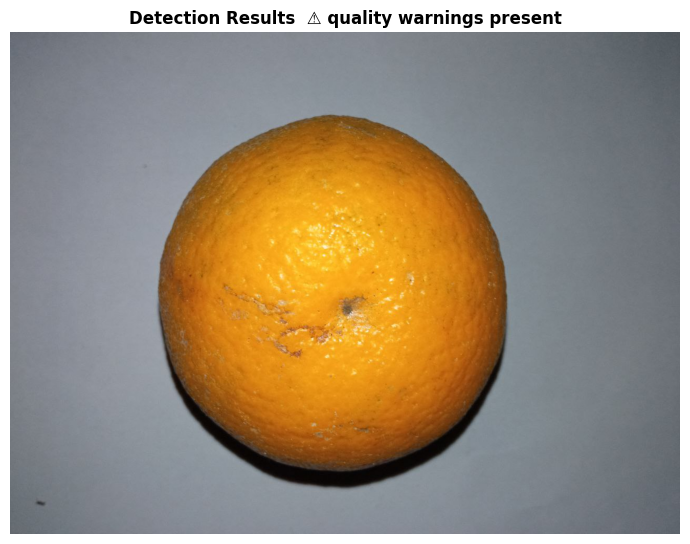


DETECTION SUMMARY
❌ Image quality too low for reliable detection
  • [HARD] Image is blurry — sharpness 24.4 (need ≥80). Edges are too soft for reliable classification.

────────────────────────────────────────────────────────────
Sample 4/4: 6150065028531863274.jpg
Ground truth: Banana-Formalin-mixed
────────────────────────────────────────────────────────────


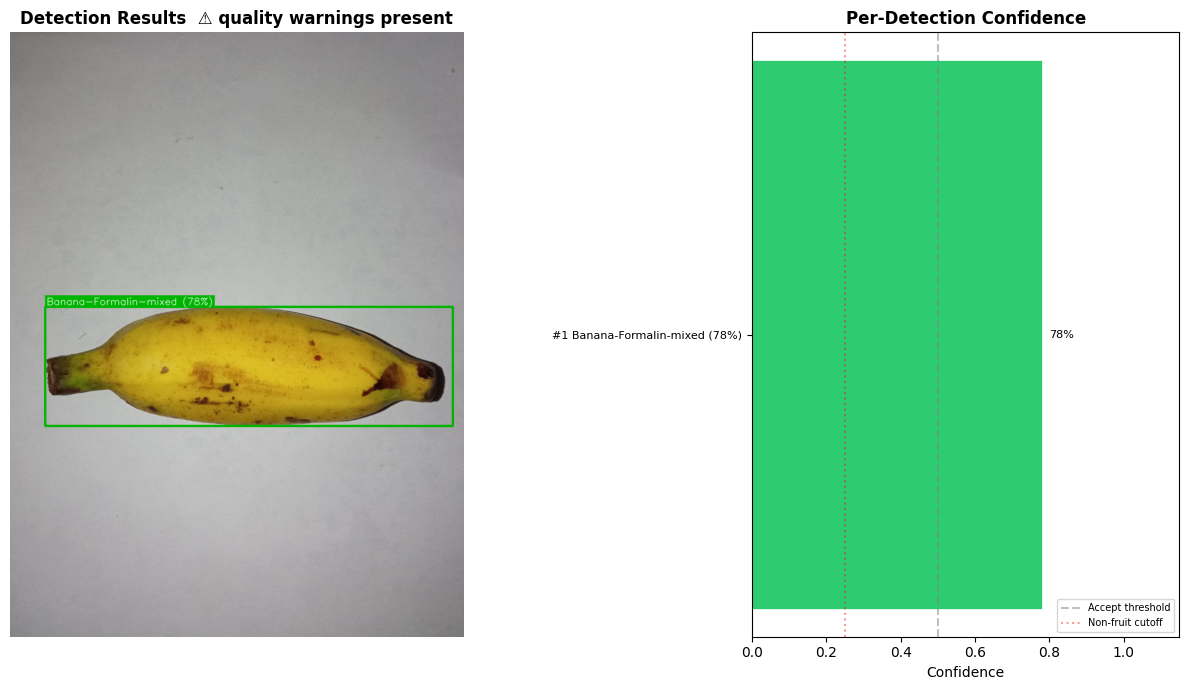


DETECTION SUMMARY
✅ 1 fruit(s) detected:
   1. Banana-Formalin-mixed (78%)
⚠️  Image quality warnings:
  • [SOFT] Image is blurry — sharpness 37.5 (need ≥80). Edges are too soft for reliable classification.


In [26]:
# ── Demo on random test-set images ─────────────────────────────────
def demo_pipeline(n_samples=4):
    """
    Pick random images from the test set and run through the
    full detection pipeline.  This demonstrates all three outcomes:
    confident fruit, uncertain, and (if present) non-fruit.
    """
    print("=" * 60)
    print("PIPELINE DEMO — random test-set samples")
    print("=" * 60)

    indices = np.random.choice(len(test_data), min(n_samples, len(test_data)),
                               replace=False)

    for i, idx in enumerate(indices):
        real_idx = test_data.indices[idx]
        path, true_label = full_dataset.samples[real_idx]
        true_name = full_dataset.classes[true_label]

        print(f"\n{'─'*60}")
        print(f"Sample {i+1}/{len(indices)}: {os.path.basename(path)}")
        print(f"Ground truth: {true_name}")
        print(f"{'─'*60}")

        result = pipeline.detect(path)
        visualize_result(result)


# Run demo
demo_pipeline(n_samples=4)

In [27]:
# ── Demo: deliberately test edge cases ──────────────────────────────
def demo_edge_cases():
    """
    Create synthetic test images that trigger each failure mode,
    so you can verify the pipeline's rejection messages.
    """
    print("\n" + "=" * 60)
    print("EDGE-CASE DEMOS")
    print("=" * 60)

    # ── 1. Blurry image ────────────────────────────────────────────
    print("\n--- Test: Blurry image ---")
    real_idx = test_data.indices[0]
    path, _ = full_dataset.samples[real_idx]
    img = Image.open(path).convert('RGB')
    img_np = np.array(img)
    blurred = cv2.GaussianBlur(img_np, (51, 51), 0)
    result = pipeline.detect(Image.fromarray(blurred))
    visualize_result(result)

    # ── 2. Very dark image ──────────────────────────────────────────
    print("\n--- Test: Very dark image ---")
    dark = (img_np * 0.05).astype(np.uint8)
    result = pipeline.detect(Image.fromarray(dark))
    visualize_result(result)

    # ── 3. Non-fruit: solid colour (not a fruit at all) ─────────────
    print("\n--- Test: Non-fruit (random noise) ---")
    noise = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)
    result = pipeline.detect(Image.fromarray(noise))
    visualize_result(result)

    # ── 4. Tiny image (below resolution threshold) ──────────────────
    print("\n--- Test: Tiny image (32×32) ---")
    tiny = img.resize((32, 32))
    result = pipeline.detect(tiny)
    visualize_result(result)

    print("\n✅ Edge-case demos complete.")


# Uncomment to run edge-case demos:
# demo_edge_cases()

# Cell 18 — Updated Mobile Export (adds pipeline config)
#
Extends the Cell-12 export with the confidence thresholds and
pipeline settings so the mobile app can replicate the same
accept/reject logic.

In [28]:
# Append pipeline settings to existing runtime_config.json
pipeline_config_path = os.path.join(EXPORT_DIR, 'runtime_config.json')
with open(pipeline_config_path, 'r') as f:
    config = json.load(f)

config.update({
    'pipeline': {
        'yolo_model':            'yolov8n',
        'yolo_confidence':       0.25,
        'min_crop_px':           32,
        'crop_padding':          0.12,
        'confidence_threshold':  0.50,
        'ambiguity_gap':         0.15,
        'non_fruit_threshold':   0.25,
        'entropy_max':           0.60,
        'quality_checks': {
            'blur_threshold':    80.0,
            'brightness_range':  [30, 240],
            'contrast_min':      20.0,
            'min_resolution':    64,
            'max_aspect_ratio':  5.0,
        },
    }
})

with open(pipeline_config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Pipeline config appended to {pipeline_config_path}")
print(json.dumps(config['pipeline'], indent=2))

✅ Pipeline config appended to mobile_model/runtime_config.json
{
  "yolo_model": "yolov8n",
  "yolo_confidence": 0.25,
  "min_crop_px": 32,
  "crop_padding": 0.12,
  "confidence_threshold": 0.5,
  "ambiguity_gap": 0.15,
  "non_fruit_threshold": 0.25,
  "entropy_max": 0.6,
  "quality_checks": {
    "blur_threshold": 80.0,
    "brightness_range": [
      30,
      240
    ],
    "contrast_min": 20.0,
    "min_resolution": 64,
    "max_aspect_ratio": 5.0
  }
}
